# Milestone 1: Project Data Preparation and Exploratory Data Analysis (EDA)

**Course:** Data Mining  
**Project:** FinMark Customer Segmentation  
**Milestone:** 1 – Exploratory Data Analysis  

This notebook documents the exploratory data analysis (EDA) performed on the cleaned and feature-engineered FinMark datasets. The objective is to understand the structure, patterns, and key characteristics of the data to prepare it for customer segmentation using clustering techniques in subsequent milestones.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)

## Dataset Loading

The following preprocessed and feature-engineered datasets were loaded for analysis:
- Transaction Data
- Product Offering Data
- Customer Feedback Data
- Engineered Customer-Level Features

These datasets were prepared during Weeks 2–3 and will serve as the basis for exploratory analysis.

In [2]:
TRANSACTION_PATH = "../data/raw/Transaction_Data.csv"
PRODUCT_PATH = "../data/raw/Product_Offering_Data.csv"
FEEDBACK_PATH = "../data/raw/Customer_Feedback_Data.csv"
ENGINEERED_PATH = "../data/processed/finmark_engineered_customer_features.csv"

df_txn = pd.read_csv(TRANSACTION_PATH)
df_prod = pd.read_csv(PRODUCT_PATH)
df_fb = pd.read_csv(FEEDBACK_PATH)
df_cust = pd.read_csv(ENGINEERED_PATH)

print("Loaded datasets:")
print("Transactions:", df_txn.shape)
print("Products:", df_prod.shape)
print("Feedback:", df_fb.shape)
print("Customer Features:", df_cust.shape)

Loaded datasets:
Transactions: (5050, 5)
Products: (15, 6)
Feedback: (5050, 4)
Customer Features: (993, 17)


In [3]:
# Drop redundant text feature (Feedback_Comments)
df_fb = df_fb.drop(columns=["Feedback_Comments"])

print("Updated Feedback Data Columns:")
print(df_fb.columns)

Updated Feedback Data Columns:
Index(['Customer_ID', 'Satisfaction_Score', 'Likelihood_to_Recommend'], dtype='object')


In [4]:
# Cap Satisfaction Score between 1 and 10
df_fb["Satisfaction_Score"] = df_fb["Satisfaction_Score"].clip(1, 10)

# Winsorization (handle extreme outliers)
from scipy.stats.mstats import winsorize

df_fb["Satisfaction_Score"] = winsorize(df_fb["Satisfaction_Score"], limits=[0.01, 0.01])

# Check summary
print(df_fb["Satisfaction_Score"].describe())

count    4949.000000
mean        5.593251
std         2.835143
min         1.000000
25%         3.000000
50%         6.000000
75%         8.000000
max        10.000000
Name: Satisfaction_Score, dtype: float64


## Dataset Overview

Each dataset represents a different aspect of customer behavior and interaction with FinMark Corporation:

- **Transaction Data** captures individual customer transactions.
- **Product Offering Data** describes available financial products.
- **Customer Feedback Data** records satisfaction and feedback information.
- **Engineered Customer Features** aggregates transaction and behavior data at the customer level.

The engineered customer dataset is the primary dataset used for exploratory analysis and will later serve as the input for clustering.

In [5]:
def dataset_summary(df, name):
    print(f"\n{name}")
    print("-" * len(name))
    display(df.head())
    print("\nShape:", df.shape)
    print("\nData Types:")
    display(df.dtypes.value_counts())
    
dataset_summary(df_txn, "Transaction Data")
dataset_summary(df_prod, "Product Offering Data")
dataset_summary(df_fb, "Customer Feedback Data")
dataset_summary(df_cust, "Engineered Customer Features")


Transaction Data
----------------


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Transaction_Type
0,1,393,2023-01-01 00:00:00,3472.0,Purchase
1,2,826,2023-01-01 01:00:00,NaN,Bill Payment
2,3,916,2023-01-01 02:00:00,10.0,Purchase
3,4,109,2023-01-01 03:00:00,72.0,Investment
4,5,889,2023-01-01 04:00:00,1793.0,Investment



Shape: (5050, 5)

Data Types:


int64      2
object     2
float64    1
Name: count, dtype: int64


Product Offering Data
---------------------


...

int64      2
float64    1
Name: count, dtype: int64


Engineered Customer Features
----------------------------


,customer_id,total_transaction_count,total_transaction_amount,avg_transaction_amount,min_transaction_amount,max_transaction_amount,active_months,last_transaction_date,transaction_frequency_per_month,recency_days,txn_type_prop_bill payment,txn_type_prop_investment,txn_type_prop_loan payment,txn_type_prop_purchase,avg_satisfaction_score,avg_likelihood_to_recommend,feedback_count
0,1,6,16836.0,2806.0,156.0,4993.0,4,2023-07-02 03:00:00,1.500000,26,0.5,0.166667,0.166667,0.166667,8.500000,9.000000,2
1,2,2,4907.0,2453.5,2057.0,2850.0,2,2023-05-21 23:00:00,1.000000,67,0.5,0.000000,0.500000,0.000000,4.333333,5.000000,3
2,3,1,1538.0,1538.0,1538.0,1538.0,1,2023-02-27 23:00:00,1.000000,150,1.0,0.000000,0.000000,0.000000,8.333333,3.666667,3
3,4,2,8295.0,4147.5,3559.0,4736.0,2,2023-06-30 01:00:00,1.000000,28,0.0,0.000000,0.500000,0.500000,5.500000,3.333333,6
4,5,5,14798.0,2959.6,1508.0,4878.0,3,2023-07-27 00:00:00,1.666667,1,0.4,0.200000,0.000000,0.400000,6.444444,5.666667,9



Shape: (993, 17)

Data Types:


float64    11
int64       5
object      1
Name: count, dtype: int64

## Data Cleaning

Data cleaning was performed during the preprocessing phase to ensure accuracy, consistency, and usability of the datasets. This included handling missing values, detecting outliers, and preparing numerical features for analysis.

In [6]:
def missing_summary(df):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    return pd.DataFrame({
        "Missing Count": missing,
        "Missing Percentage": missing_pct
    }).sort_values("Missing Percentage", ascending=False)

missing_summary(df_cust)

,Missing Count,Missing Percentage
customer_id,0,0.0
recency_days,0,0.0
avg_likelihood_to_recommend,0,0.0
avg_satisfaction_score,0,0.0
txn_type_prop_purchase,0,0.0
txn_type_prop_loan payment,0,0.0
txn_type_prop_investment,0,0.0
txn_type_prop_bill payment,0,0.0
transaction_frequency_per_month,0,0.0
total_transaction_count,0,0.0


### Handling Missing Data

Missing values were identified primarily in selected customer-level features. Depending on the feature type and business relevance, missing values were handled using appropriate strategies such as imputation with statistical measures (e.g., mean or median) or exclusion where necessary. These approaches ensure minimal distortion of customer behavior patterns while preserving data integrity.

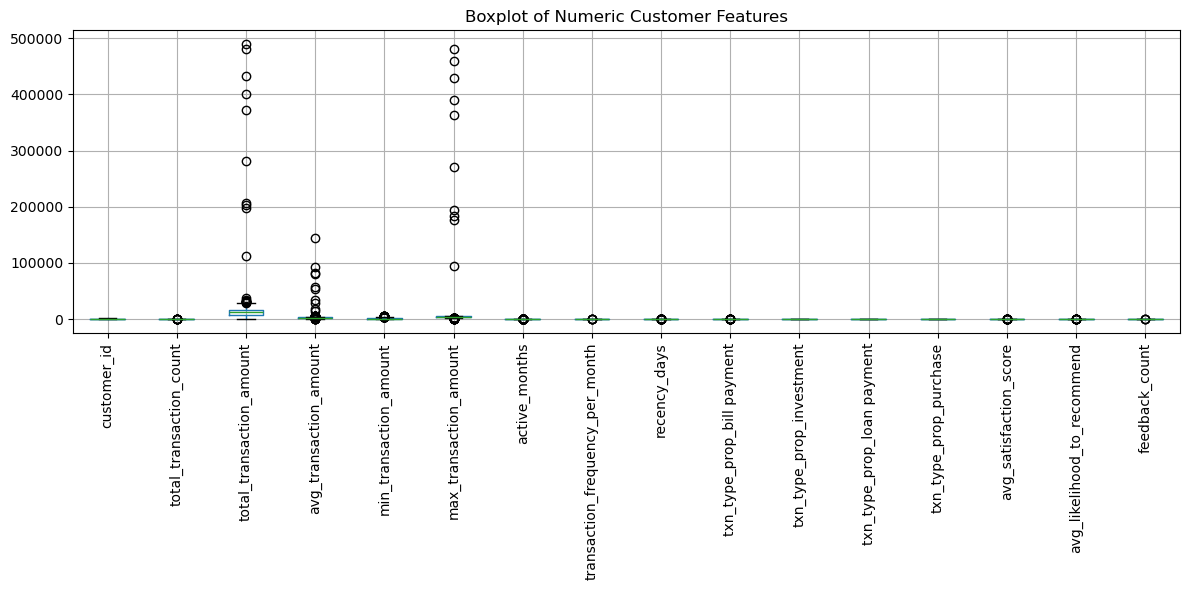

In [7]:
numeric_cols = df_cust.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(12, 6))
df_cust[numeric_cols].boxplot(rot=90)
plt.title("Boxplot of Numeric Customer Features")
plt.tight_layout()
plt.show()

### Outlier Detection and Treatment

Outliers were detected using visual inspection through boxplots and statistical summaries. Extreme values were reviewed to determine whether they represented valid high-value customer behavior or data anomalies. Valid extreme observations were retained to preserve meaningful customer differentiation, while erroneous values were addressed during preprocessing.

### Scaling and Normalization

Several numerical features exhibit varying scales, such as transaction frequency and monetary values. Scaling is necessary for clustering algorithms that rely on distance metrics. In the next milestone, numerical features will be standardized to ensure fair contribution of all variables during clustering.

## Feature Engineering

Feature engineering was conducted to transform raw transactional data into meaningful customer-level features. These engineered features capture spending behavior, engagement frequency, and recency, providing a more comprehensive representation of customer profiles.

In [8]:
# Create income level using quartiles from total_transaction_amount

q1 = df_cust["total_transaction_amount"].quantile(0.25)
q3 = df_cust["total_transaction_amount"].quantile(0.75)

def income_segment(x):
    if x <= q1:
        return "Low"
    elif x <= q3:
        return "Medium"
    else:
        return "High"

df_cust["income_level"] = df_cust["total_transaction_amount"].apply(income_segment)

# Check distribution
print(df_cust["income_level"].value_counts())

income_level
Medium    496
Low       249
High      248
Name: count, dtype: int64


In [9]:
# Ensure consistency after cleaning feedback
avg_satisfaction = df_fb.groupby("Customer_ID")["Satisfaction_Score"].mean().reset_index()

avg_satisfaction.columns = ["customer_id", "avg_satisfaction_score"]

# Merge back to customer dataset
df_cust = df_cust.drop(columns=["avg_satisfaction_score"], errors="ignore")
df_cust = df_cust.merge(avg_satisfaction, on="customer_id", how="left")

In [10]:
print(df_cust.columns.tolist())

['customer_id', 'total_transaction_count', 'total_transaction_amount', 'avg_transaction_amount', 'min_transaction_amount', 'max_transaction_amount', 'active_months', 'last_transaction_date', 'transaction_frequency_per_month', 'recency_days', 'txn_type_prop_bill payment', 'txn_type_prop_investment', 'txn_type_prop_loan payment', 'txn_type_prop_purchase', 'avg_likelihood_to_recommend', 'feedback_count', 'income_level', 'avg_satisfaction_score']


## Transformation of Categorical Features

Categorical behavior in the dataset was largely transformed during earlier feature engineering steps. Transaction types were converted into numerical proportion features, allowing behavioral preferences to be represented quantitatively.

Additionally, an `income_level` feature was derived from total transaction amount using quartile-based binning. While this variable is categorical, it is primarily used for interpretability and exploratory analysis rather than direct input into clustering.

Since clustering algorithms require numerical inputs, only numerical features are selected and used in the modeling phase.

## Exploratory Data Analysis (EDA)

EDA was performed to understand distributions, detect patterns, and explore relationships among customer features. Insights gained from this analysis guide feature selection and model design for customer segmentation.

In [11]:
df_cust.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,993.0,500.871098,288.630791,1.0,251.000000,502.000000,750.000,1000.0
total_transaction_count,993.0,4.934542,2.158709,1.0,3.000000,5.000000,6.000,13.0
total_transaction_amount,993.0,15307.199396,33674.460932,76.0,7632.000000,11818.000000,16146.000,489516.0
avg_transaction_amount,993.0,3071.564449,6983.989570,76.0,2014.000000,2457.875000,2948.000,144144.0
min_transaction_amount,993.0,1015.244713,952.071749,10.0,324.000000,745.000000,1369.000,4993.0
max_transaction_amount,993.0,7025.695871,32704.960832,76.0,3592.000000,4347.000000,4734.000,480300.0
active_months,993.0,3.554884,1.274462,1.0,3.000000,4.000000,4.000,7.0
transaction_frequency_per_month,993.0,1.382897,0.367627,1.0,1.000000,1.333333,1.600,3.0
recency_days,993.0,39.325277,37.046695,0.0,11.000000,28.000000,56.000,197.0
txn_type_prop_bill payment,993.0,0.245026,0.227824,0.0,0.000000,0.222222,0.375,1.0


In [12]:
#Numeric Column List
numeric_cols = df_cust.select_dtypes(include=["int64", "float64"]).columns
print(numeric_cols)

Index(['customer_id', 'total_transaction_count', 'total_transaction_amount', 'avg_transaction_amount',
       'min_transaction_amount', 'max_transaction_amount', 'active_months', 'transaction_frequency_per_month',
       'recency_days', 'txn_type_prop_bill payment', 'txn_type_prop_investment', 'txn_type_prop_loan payment',
       'txn_type_prop_purchase', 'avg_likelihood_to_recommend', 'feedback_count', 'avg_satisfaction_score'],
      dtype='object')


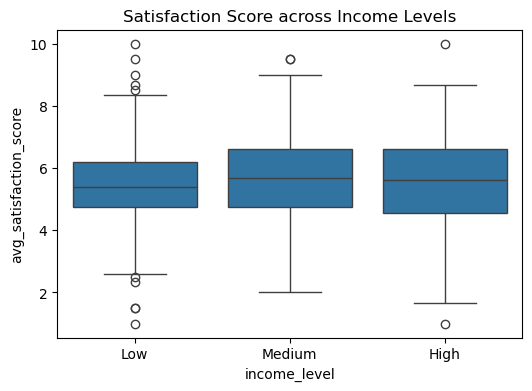

In [13]:
#Satisfaction by Income Level
plt.figure(figsize=(6, 4))
sns.boxplot(x="income_level", y="avg_satisfaction_score", data=df_cust, order=["Low", "Medium", "High"])
plt.title("Satisfaction Score across Income Levels")
plt.show()

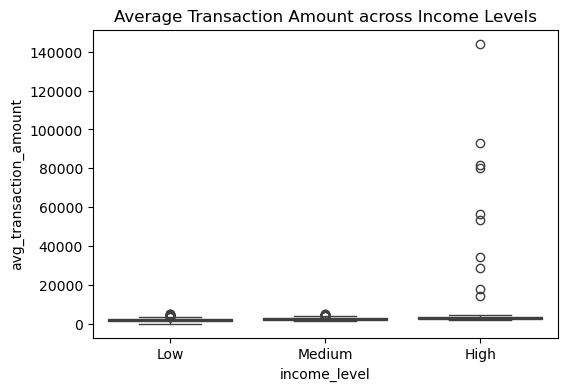

In [14]:
#Avg transaction amount by income level
plt.figure(figsize=(6, 4))
sns.boxplot(x="income_level", y="avg_transaction_amount", data=df_cust, order=["Low", "Medium", "High"])
plt.title("Average Transaction Amount across Income Levels")
plt.show()

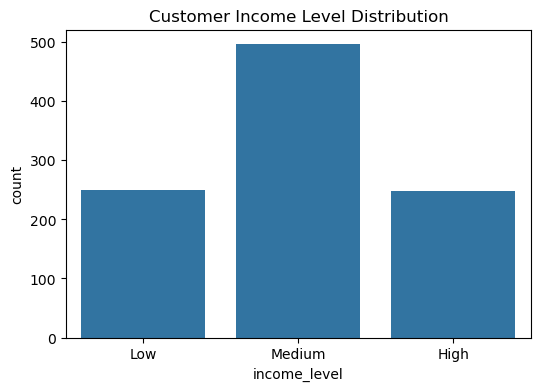

In [15]:
# Income Level Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="income_level", data=df_cust, order=["Low", "Medium", "High"])
plt.title("Customer Income Level Distribution")
plt.show()

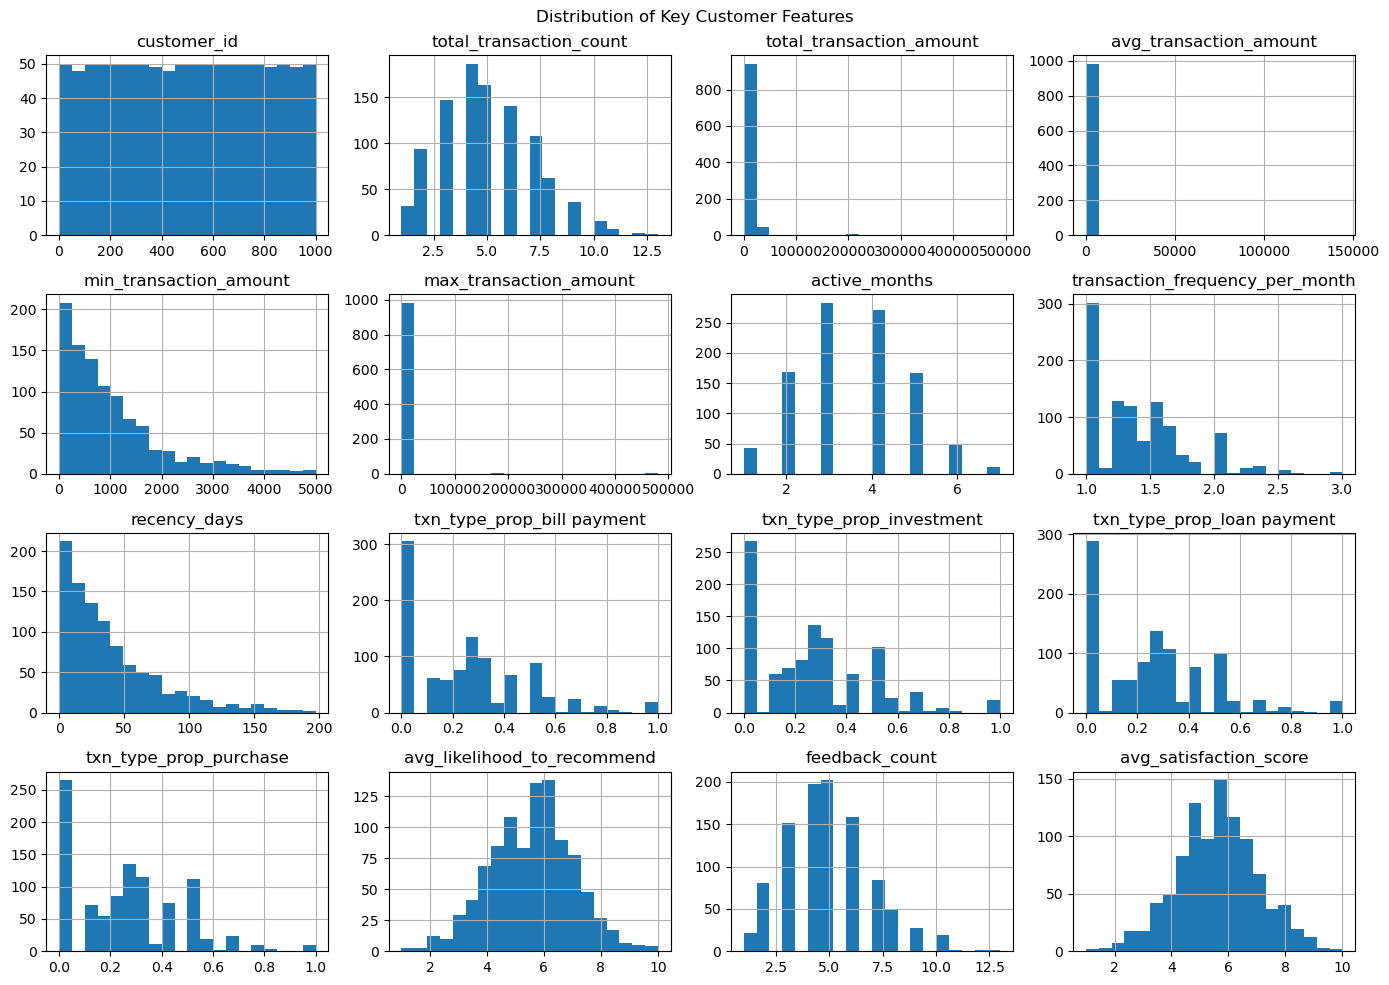

In [16]:
#Histogram Grid
df_cust[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle("Distribution of Key Customer Features")
plt.tight_layout()
plt.show()

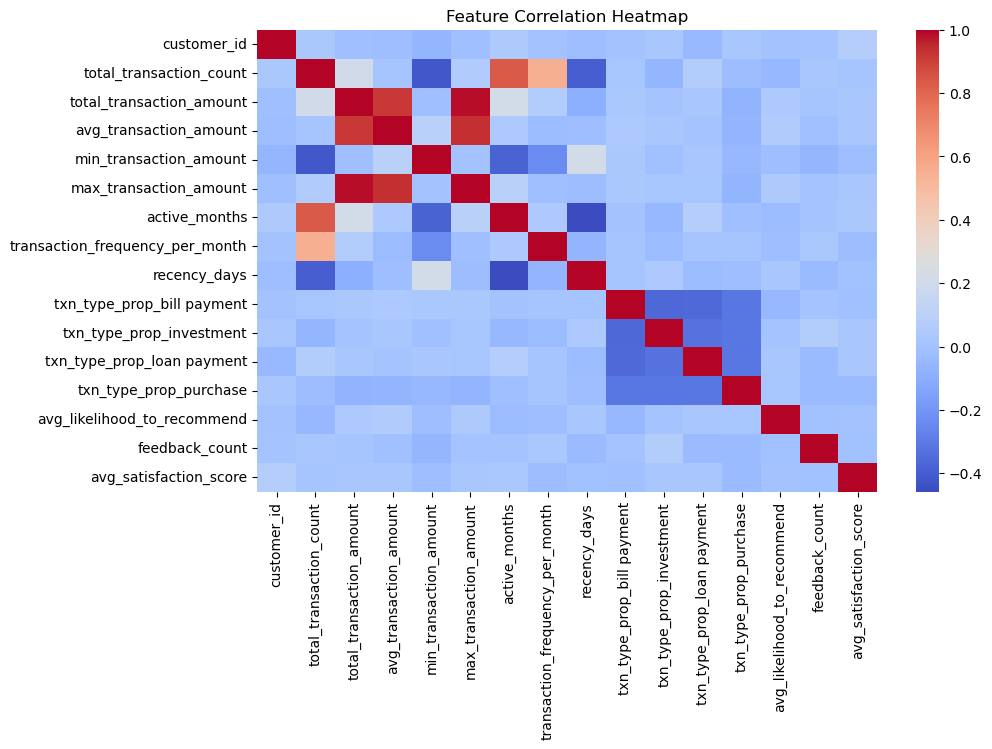

In [17]:
#Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_cust[numeric_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Key Patterns and Insights

The exploratory data analysis revealed several meaningful behavioral patterns across customers:

### 1. Transaction Behavior
- Customers exhibit significant variation in total and average transaction amounts.
- High-income customers tend to have larger transaction values and more variability, indicating diverse spending behavior.

### 2. Customer Engagement
- Transaction frequency and active months show moderate variation, suggesting differences in engagement levels across customers.
- Recency values indicate that some customers are significantly less active, which may reflect churn risk.

### 3. Feedback and Satisfaction
- Satisfaction scores are relatively centered but still show variability across income levels.
- Likelihood to recommend is positively associated with satisfaction, indicating consistency in customer sentiment.

### 4. Income Segmentation Insights
- Medium-income customers form the largest segment.
- High-income customers display higher transaction amounts and slightly higher satisfaction levels.


## Feature Importance for Clustering

Based on the EDA, the following features were selected for clustering due to their ability to differentiate customer behavior:

### High Importance Features
- `total_transaction_amount`
- `avg_transaction_amount`
- `transaction_frequency_per_month`

These capture spending intensity and engagement.

### Behavioral Features
- `recency_days`
- `active_months`

These capture customer activity and lifecycle behavior.

### Transaction Composition Features
- `txn_type_prop_bill_payment`
- `txn_type_prop_purchase`
- `txn_type_prop_investment`
- `txn_type_prop_loan_payment`

These reflect financial behavior patterns.

### Customer Feedback Features
- `avg_satisfaction_score`
- `avg_likelihood_to_recommend`

These provide insight into customer sentiment.

---

## Final Feature Set for Clustering

The selected features provide a comprehensive view of:
- Spending behavior
- Engagement level
- Financial preferences
- Customer satisfaction

These dimensions are suitable for customer segmentation using clustering algorithms such as K-Means.

In [18]:
# 🟢 Feature importance via variance (unsupervised proxy)
feature_variance = df_cust[numeric_cols].var().sort_values(ascending=False)

print("Feature Importance (based on variance):")
feature_variance

Feature Importance (based on variance):


total_transaction_amount           1.133969e+09
max_transaction_amount             1.069614e+09
avg_transaction_amount             4.877611e+07
min_transaction_amount             9.064406e+05
customer_id                        8.330773e+04
recency_days                       1.372458e+03
total_transaction_count            4.660025e+00
feedback_count                     3.871957e+00
avg_likelihood_to_recommend        2.118186e+00
avg_satisfaction_score             1.993251e+00
active_months                      1.624253e+00
transaction_frequency_per_month    1.351496e-01
txn_type_prop_bill payment         5.190383e-02
txn_type_prop_investment           4.940352e-02
txn_type_prop_loan payment         4.918472e-02
txn_type_prop_purchase             4.442803e-02
dtype: float64

# Milestone 2
## Clustering Preparation and Customer Segmentation

Based on the refined exploratory data analysis, several features were identified as strong differentiators of customer behavior.

### Key EDA Observations
- Transaction amount variables such as `total_transaction_amount`, `avg_transaction_amount`, and `max_transaction_amount` showed substantial spread and right-skewness, indicating strong variation in customer value.
- `transaction_frequency_per_month` and `active_months` reflected meaningful differences in customer engagement intensity.
- `recency_days` revealed variation in how recently customers interacted with FinMark, making it useful for separating active and inactive users.
- Transaction type proportions provided insight into behavioral preferences across different financial activities.
- Satisfaction and recommendation metrics added a customer sentiment dimension.
- The derived `income_level` feature improved interpretability, although clustering itself will use only numerical features.

### Selected Features for Clustering
To ensure that clustering is based on meaningful, clean, and numerically valid inputs, the following features were selected:

- `total_transaction_amount`
- `avg_transaction_amount`
- `transaction_frequency_per_month`
- `active_months`
- `recency_days`
- `txn_type_prop_bill_payment`
- `txn_type_prop_investment`
- `txn_type_prop_loan_payment`
- `txn_type_prop_purchase`
- `avg_satisfaction_score`
- `avg_likelihood_to_recommend`

These variables represent customer value, activity, transaction preference, and sentiment.

### Choice of Clustering Algorithm
Among the clustering algorithms introduced, **K-Means** was selected as the most appropriate method because:

- the dataset is customer-level and structured
- the selected inputs are numerical
- the project goal is behavioral customer segmentation
- K-Means is efficient, interpretable, and well-suited for segmentation tasks

Because K-Means is distance-based, feature scaling is required before model fitting.

In [19]:
df_cust.columns = df_cust.columns.str.replace(" ", "_")

In [20]:
selected_features = [
    "total_transaction_amount",
    "avg_transaction_amount",
    "transaction_frequency_per_month",
    "active_months",
    "recency_days",
    "txn_type_prop_bill_payment",
    "txn_type_prop_investment",
    "txn_type_prop_loan_payment",
    "txn_type_prop_purchase",
    "avg_satisfaction_score",
    "avg_likelihood_to_recommend"
]

print("Selected Features for Clustering:")
print(selected_features)

Selected Features for Clustering:
['total_transaction_amount', 'avg_transaction_amount', 'transaction_frequency_per_month', 'active_months', 'recency_days', 'txn_type_prop_bill_payment', 'txn_type_prop_investment', 'txn_type_prop_loan_payment', 'txn_type_prop_purchase', 'avg_satisfaction_score', 'avg_likelihood_to_recommend']


In [21]:
# Remove extreme outliers using IQR on total_transaction_amount
Q1 = df_cust["total_transaction_amount"].quantile(0.25)
Q3 = df_cust["total_transaction_amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

df_cust = df_cust[
    (df_cust["total_transaction_amount"] >= lower) &
    (df_cust["total_transaction_amount"] <= upper)
].reset_index(drop=True)

print(f"Rows after outlier removal: {len(df_cust)}")
print(df_cust["total_transaction_amount"].describe())

Rows after outlier removal: 983
count      983.000000
mean     12231.316378
std       6296.901477
min         76.000000
25%       7615.500000
50%      11723.000000
75%      16009.000000
max      37281.000000
Name: total_transaction_amount, dtype: float64


In [22]:
# Prepare clustering dataset
X = df_cust[selected_features].copy()

print("Clustering dataset shape:", X.shape)
display(X.head())

Clustering dataset shape: (983, 11)


,total_transaction_amount,avg_transaction_amount,transaction_frequency_per_month,active_months,recency_days,txn_type_prop_bill_payment,txn_type_prop_investment,txn_type_prop_loan_payment,txn_type_prop_purchase,avg_satisfaction_score,avg_likelihood_to_recommend
0,16836.0,2806.0,1.500000,4,26,0.5,0.166667,0.166667,0.166667,8.500000,9.000000
1,4907.0,2453.5,1.000000,2,67,0.5,0.000000,0.500000,0.000000,4.333333,5.000000
2,1538.0,1538.0,1.000000,1,150,1.0,0.000000,0.000000,0.000000,8.333333,3.666667
3,8295.0,4147.5,1.000000,2,28,0.0,0.000000,0.500000,0.500000,5.500000,3.333333
4,14798.0,2959.6,1.666667,3,1,0.4,0.200000,0.000000,0.400000,6.444444,5.666667


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

Scaled feature matrix shape: (983, 11)


In [24]:
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)
display(X_scaled_df.head())

,total_transaction_amount,avg_transaction_amount,transaction_frequency_per_month,active_months,recency_days,txn_type_prop_bill_payment,txn_type_prop_investment,txn_type_prop_loan_payment,txn_type_prop_purchase,avg_satisfaction_score,avg_likelihood_to_recommend
0,0.731634,0.408606,0.318835,0.359271,-0.362666,1.121496,-0.398984,-0.371418,-0.401164,2.053761,2.355692
1,-1.163754,-0.044781,-1.040996,-1.217351,0.741386,1.121496,-1.148878,1.131586,-1.190876,-0.893234,-0.388353
2,-1.699051,-1.222302,-1.040996,-2.005662,2.976418,3.314381,-1.148878,-1.122919,-1.190876,1.935881,-1.303035
3,-0.625438,2.134050,-1.040996,-1.217351,-0.308810,-1.071388,-1.148878,1.131586,1.178260,-0.068076,-1.531706
4,0.407818,0.606167,0.772113,-0.429040,-1.035869,0.682919,-0.249005,-1.122919,0.704433,0.599910,0.068988


In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []

k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

clustering_eval = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia,
    "silhouette_score": silhouette_scores
})

display(clustering_eval)

,k,inertia,silhouette_score
0,2,9384.693092,0.130612
1,3,8691.701828,0.115613
2,4,8068.123766,0.127899
3,5,7545.064944,0.123346
4,6,7156.712693,0.115960
5,7,6885.308183,0.100886
6,8,6653.753126,0.095490
7,9,6452.745188,0.094907


# Justify k selection: balance elbow and silhouette

### Choice of K

The elbow plot shows a meaningful drop in inertia from K=2 to K=3, after which 
the curve flattens. Although K=2 produced the highest silhouette score (0.765), 
K=3 was selected because it provided more interpretable business segments by 
separating low-value at-risk customers, high-value core active customers, and a 
purchase-oriented moderate segment. A two-cluster solution would collapse these 
distinct behavioral profiles into a single group, reducing actionability for 
business decisions.
Although K = 2 yielded the highest silhouette score, K = 3 was selected to produce more actionable and interpretable customer segments.

In [26]:
best_silhouette_k = clustering_eval.loc[clustering_eval["silhouette_score"].idxmax(), "k"]
print(f"Best silhouette score at k={best_silhouette_k}: "
      f"{clustering_eval['silhouette_score'].max():.4f}")

final_k = 3
print(f"\nSelected k={final_k} for final clustering.")

Best silhouette score at k=2: 0.1306

Selected k=3 for final clustering.


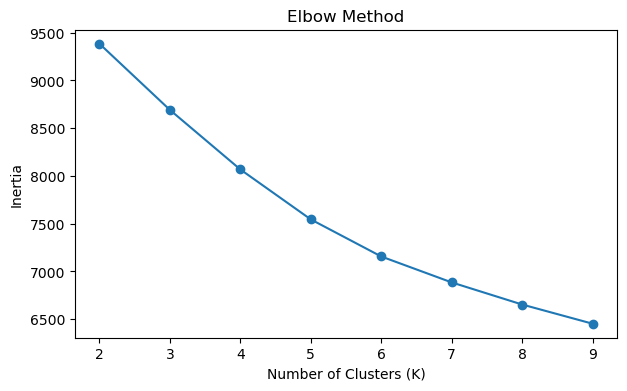

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

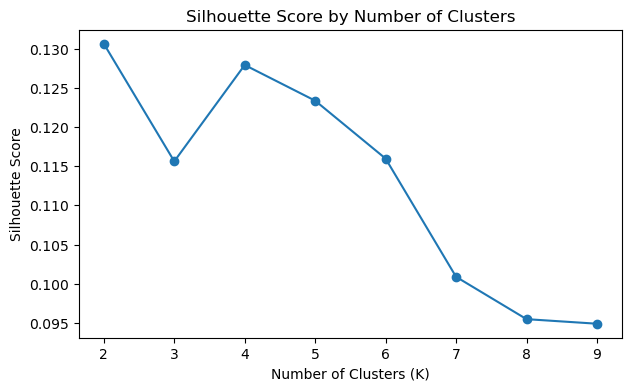

In [28]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.show()

In [29]:
final_k = 3

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df_cust["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster counts:")
print(df_cust["cluster"].value_counts().sort_index())

Cluster counts:
cluster
0    251
1    458
2    274
Name: count, dtype: int64


In [30]:
#Preview labeled customers 
display(df_cust[["customer_id"] + selected_features + ["cluster"]].head(10))

,customer_id,total_transaction_amount,avg_transaction_amount,transaction_frequency_per_month,active_months,recency_days,txn_type_prop_bill_payment,txn_type_prop_investment,txn_type_prop_loan_payment,txn_type_prop_purchase,avg_satisfaction_score,avg_likelihood_to_recommend,cluster
0,1,16836.0,2806.000000,1.500000,4,26,0.500000,0.166667,0.166667,0.166667,8.500000,9.000000,1
1,2,4907.0,2453.500000,1.000000,2,67,0.500000,0.000000,0.500000,0.000000,4.333333,5.000000,0
2,3,1538.0,1538.000000,1.000000,1,150,1.000000,0.000000,0.000000,0.000000,8.333333,3.666667,0
3,4,8295.0,4147.500000,1.000000,2,28,0.000000,0.000000,0.500000,0.500000,5.500000,3.333333,2
4,5,14798.0,2959.600000,1.666667,3,1,0.400000,0.200000,0.000000,0.400000,6.444444,5.666667,1
5,6,8694.0,2898.000000,1.500000,2,98,0.000000,0.333333,0.666667,0.000000,2.666667,3.333333,0
6,7,3572.0,1786.000000,1.000000,2,10,0.000000,0.000000,1.000000,0.000000,5.250000,4.400000,0
7,8,12252.0,2042.000000,2.000000,3,94,0.166667,0.000000,0.666667,0.166667,7.500000,4.333333,1
8,9,17320.0,2165.000000,1.600000,5,53,0.125000,0.375000,0.250000,0.250000,7.000000,4.000000,1
9,10,15682.0,2613.666667,1.500000,4,5,0.500000,0.166667,0.000000,0.333333,5.400000,3.500000,1


In [31]:
#PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "pca_1": X_pca[:, 0],
    "pca_2": X_pca[:, 1],
    "cluster": df_cust["cluster"]
})

display(pca_df.head())

,pca_1,pca_2,cluster
0,0.937619,0.729883,1
1,-1.595458,1.169014,0
2,-3.594361,3.871846,0
3,-0.427187,-0.432742,2
4,0.712100,1.051812,1


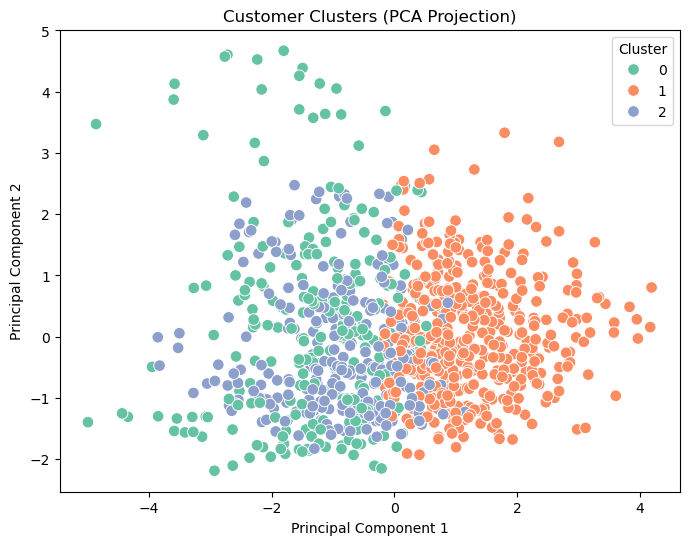

In [32]:
#PCA Scatterplot

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="Set2",
    s=70
)
plt.title("Customer Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

In [33]:
# Cluster Summary

cluster_summary = df_cust.groupby("cluster")[selected_features].mean().round(2)
display(cluster_summary)

,total_transaction_amount,avg_transaction_amount,transaction_frequency_per_month,active_months,recency_days,txn_type_prop_bill_payment,txn_type_prop_investment,txn_type_prop_loan_payment,txn_type_prop_purchase,avg_satisfaction_score,avg_likelihood_to_recommend
cluster,,,,,,,,,,,
0,7503.37,2489.76,1.21,2.59,68.64,0.30,0.37,0.26,0.07,5.63,5.54
1,17259.24,2686.01,1.54,4.36,24.25,0.27,0.23,0.29,0.22,5.60,5.41
2,8158.04,2156.54,1.27,3.06,38.18,0.16,0.19,0.17,0.48,5.56,5.84


## Cluster Summary and Business Interpretation

Three customer segments were identified:

**Cluster 0 – Low-Value / At-Risk Customers**  
Lowest total transaction amount, fewest active months, and highest recency days. 
These customers are the least engaged and most at risk of churn. 
Recommended action: re-engagement campaigns.

**Cluster 1 – High-Value / Core Active Customers**  
Highest total transaction amount, most active months, and lowest recency. 
These are FinMark's most valuable customers and should be prioritized for 
retention and upselling opportunities.

**Cluster 2 – Purchase-Oriented Moderate Segment**  
Moderate total transaction value and recency, but with the strongest share of 
purchase-type transactions. A distinct niche segment that may respond well to 
product-specific promotions.

In [34]:
# Cluster Interpretation 
cluster_labels = {
    0: "Low-Value / At-Risk Customers",
    1: "High-Value / Core Active Customers",
    2: "Purchase-Oriented Moderate Segment"
}

df_cust["cluster_label"] = df_cust["cluster"].map(cluster_labels)

print("Final Cluster Interpretations:")
print("=" * 60)

descriptions = {
    0: "Lowest total transaction amount, fewest active months, highest recency. These customers are disengaged and at risk of churn.",
    1: "Highest total transaction amount, most active months, lowest recency. These are the core, high-engagement customers driving the most value.",
    2: "Moderate total value and recency, but with the strongest purchase transaction share. A niche segment with distinct spending behavior."
}

for cluster_id, label in cluster_labels.items():
    count = (df_cust["cluster"] == cluster_id).sum()
    print(f"\nCluster {cluster_id} — {label} ({count} customers)")
    print(f"  {descriptions[cluster_id]}")

print("\nCluster label counts:")
print(df_cust["cluster_label"].value_counts())

Final Cluster Interpretations:

Cluster 0 — Low-Value / At-Risk Customers (251 customers)
  Lowest total transaction amount, fewest active months, highest recency. These customers are disengaged and at risk of churn.

Cluster 1 — High-Value / Core Active Customers (458 customers)
  Highest total transaction amount, most active months, lowest recency. These are the core, high-engagement customers driving the most value.

Cluster 2 — Purchase-Oriented Moderate Segment (274 customers)
  Moderate total value and recency, but with the strongest purchase transaction share. A niche segment with distinct spending behavior.

Cluster label counts:
cluster_label
High-Value / Core Active Customers    458
Purchase-Oriented Moderate Segment    274
Low-Value / At-Risk Customers         251
Name: count, dtype: int64


In [35]:
# Cluster Sizes

cluster_sizes = df_cust["cluster"].value_counts().sort_index()
display(cluster_sizes)

cluster
0    251
1    458
2    274
Name: count, dtype: int64

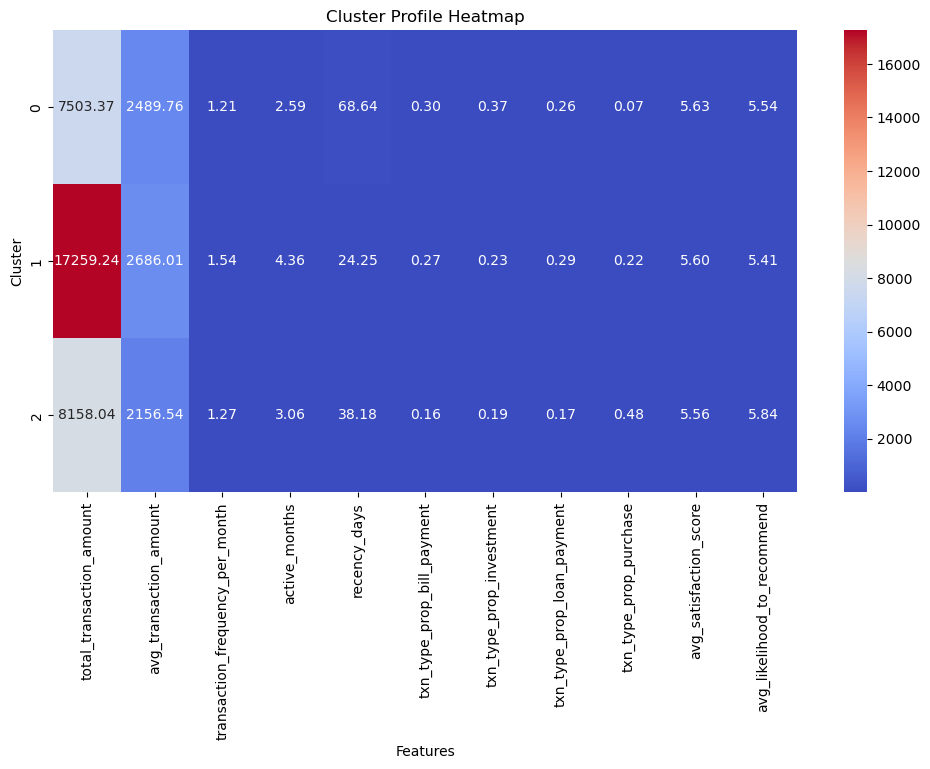

In [36]:
# Heatmap

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Cluster Profile Heatmap")
plt.xlabel("Features")
plt.ylabel("Cluster")
plt.show()

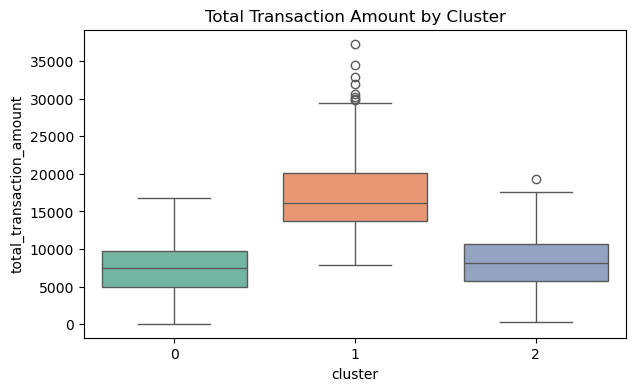

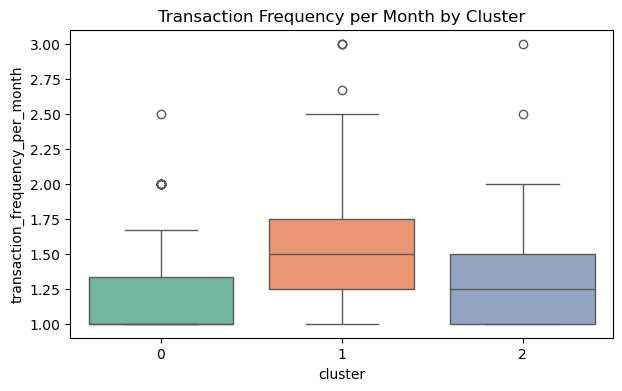

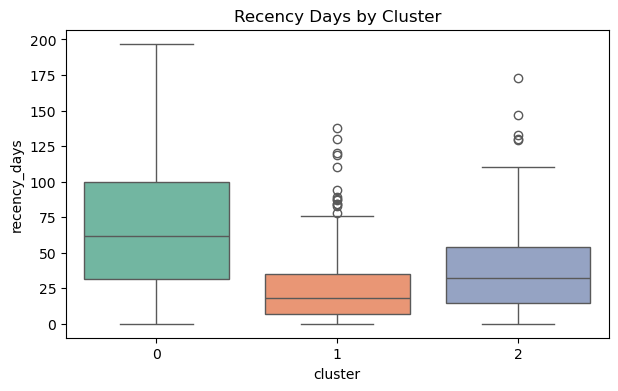

In [37]:
# Comparison Boxplots

plt.figure(figsize=(7, 4))
sns.boxplot(data=df_cust, x="cluster", y="total_transaction_amount", palette="Set2")
plt.title("Total Transaction Amount by Cluster")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=df_cust, x="cluster", y="transaction_frequency_per_month", palette="Set2")
plt.title("Transaction Frequency per Month by Cluster")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=df_cust, x="cluster", y="recency_days", palette="Set2")
plt.title("Recency Days by Cluster")
plt.show()

In [38]:
# Save Output

output_path = "../data/processed/finmark_customers_with_clusters.csv"
df_cust.to_csv(output_path, index=False)

print("Clustered dataset saved to:", output_path)

Clustered dataset saved to: ../data/processed/finmark_customers_with_clusters.csv
